# What is the most optimal skill to learn for data Analysts?

## Methodology

1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent.

In [1]:
#Libraries import code
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from datasets import load_dataset

#datasets/dataframes to be used
dataset = load_dataset('coachprerakmehta/data_jobs')
df = dataset['train'].to_pandas()

#quick data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if isinstance(skill_list, str) and pd.notna(skill_list) else skill_list)

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [4]:
df_DA_US =df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [6]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False)

In [7]:
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

In [9]:
DA_job_count =len(df_DA_US)

df_DA_skills['skill_percent']= (df_DA_skills['skill_count'] / DA_job_count)*100

df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
couchbase,1,160515.0,0.022989
chainer,1,100000.0,0.022989
chef,1,85000.0,0.022989


In [11]:
skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

In [12]:
from adjustText import adjust_text

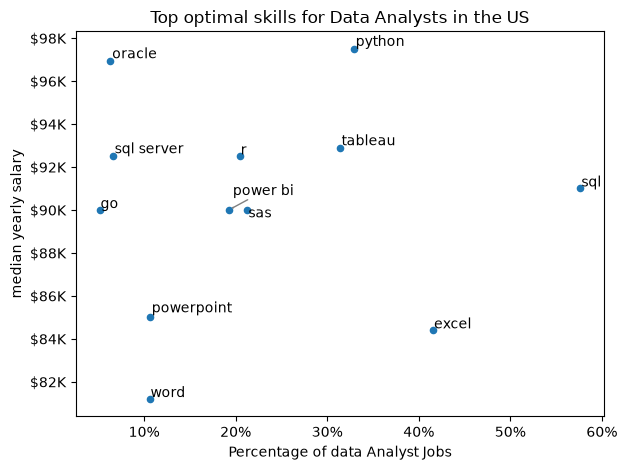

In [ ]:
#plot function defining the chart type, x and y axis
df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
from matplotlib.ticker import PercentFormatter
#xlabel
plt.xlabel('Percentage of Data Analyst Jobs')
#ylabel
plt.ylabel('median yearly salary')
#title
plt.title('Top optimal skills for Data Analysts in the US')
#adjust properly
plt.tight_layout()
#list of text that will show on the labels
texts = []
#this will add the labels on the chart since itself pyplot doesnt allow to do it requires the following code to be done
for i, txt in enumerate(df_DA_skills_high_demand.index):
    #this will basically create the loop to get every detail to place the label in the proper scatter dot
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i],txt))
#adjust text new function imported, this to work properly with the code overall since will do basically the proper word arangement for the dots
adjust_text(texts, arrowprops=dict(arrowstyle='->',color='gray',lw=1))
#axis call function to get current axis
ax = plt.gca()
#this will modify the y axis format to show as #k instead of full number
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
#display chart
plt.show()

In [19]:
df_tech = df['job_type_skills'].copy()

#remove dups
df_tech = df_tech.drop_duplicates()

#remove nan
df_tech = df_tech.dropna()

#mergedictionaries into one single dict
tech_dict = {}
for row in df_tech:
    row_dict = ast.literal_eval(row) #convert string to dictionary
    for key, value in row_dict.items():
        if key in tech_dict: #if key already exist in tech_dict, add value to existing values
            tech_dict[key] += value
        else:  #if key doesnt exist in tech_dict, add key and value
            tech_dict[key] = value

#remove dups, changing to set then to list
for key, value in tech_dict.items():
    tech_dict[key] = list(set(value))

#tech_dict

In [20]:
df_technology = pd.DataFrame(list(tech_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

In [22]:
df_plot_merged = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

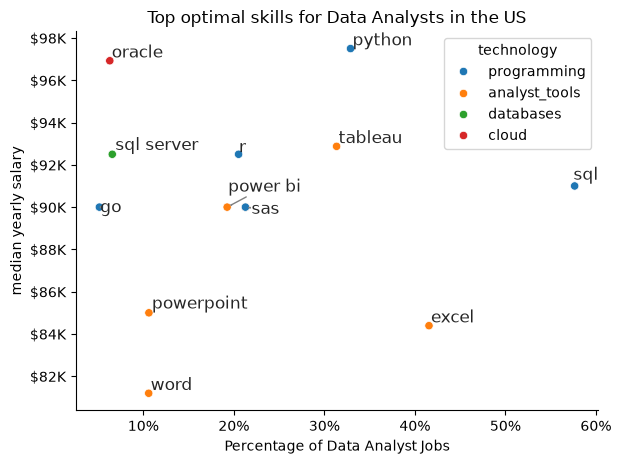

In [24]:
#plot function defining the chart type, x and y axis

sns.scatterplot(
    data=df_plot_merged,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

#remove border from chart
sns.despine()
sns.set_theme(style='ticks')
from matplotlib.ticker import PercentFormatter
#xlabel
plt.xlabel('Percentage of Data Analyst Jobs')
#ylabel
plt.ylabel('median yearly salary')
#title
plt.title('Top optimal skills for Data Analysts in the US')
#adjust properly
plt.tight_layout()
#list of text that will show on the labels
texts = []
#this will add the labels on the chart since itself pyplot doesnt allow to do it requires the following code to be done
for i, txt in enumerate(df_DA_skills_high_demand.index):
    #this will basically create the loop to get every detail to place the label in the proper scatter dot
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i],txt))
#adjust text new function imported, this to work properly with the code overall since will do basically the proper word arangement for the dots
adjust_text(texts, arrowprops=dict(arrowstyle='->',color='gray',lw=1))
#axis call function to get current axis
ax = plt.gca()
#this will modify the y axis format to show as #k instead of full number
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
#display chart
plt.show()